<a href="https://colab.research.google.com/github/CoderCouple/hands-on-pytorch/blob/main/ch_02_pytorch_binary_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#import the libraries
from sklearn.model_selection import train_test_split
from sklearn.datasets import make_circles
import numpy  as np

In [ ]:
n_samples =1000

X,Y = make_circles(
    n_samples=n_samples,
    noise=0.03,
    random_state=28
)

X, Y

(array([[ 0.71731677,  0.67579825],
        [-0.69320852, -0.75714993],
        [ 0.21432394, -1.01570213],
        ...,
        [-0.90456832, -0.32691341],
        [ 0.76153367,  0.12285871],
        [-1.0114137 , -0.06365047]]),
 array([0, 0, 0, 1, 0, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0, 1, 1, 1, 1,
        1, 1, 0, 1, 1, 0, 0, 1, 1, 1, 1, 1, 0, 1, 1, 0, 0, 0, 1, 1, 0, 1,
        1, 1, 1, 0, 1, 0, 1, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
        1, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 1, 0, 1, 1,
        0, 0, 0, 1, 1, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 1, 0, 0, 0, 0, 1, 0,
        0, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 1, 0, 1, 1, 0, 1, 0, 1, 0, 0,
        0, 1, 0, 0, 0, 1, 1, 0, 0, 1, 0, 1, 1, 0, 0, 1, 0, 1, 1, 1, 0, 0,
        0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 0, 1, 0, 1, 1, 0,
        0, 1, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0,
        1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0,
        1, 1, 0, 0, 1, 0, 1, 

In [ ]:
X[:5, :], Y[:5]

(array([[ 0.71731677,  0.67579825],
        [-0.69320852, -0.75714993],
        [ 0.21432394, -1.01570213],
        [ 0.69808324, -0.4561967 ],
        [-0.62311553,  0.69825747]]),
 array([0, 0, 0, 1, 0]))

In [ ]:
import pandas as pd
pd.DataFrame(
    {
        "x1":X[:, 0],
        "x2":X[:, 1],
        "y":Y
    }
)

,x1,x2,y
0,0.717317,0.675798,0
1,-0.693209,-0.757150,0
2,0.214324,-1.015702,0
3,0.698083,-0.456197,1
4,-0.623116,0.698257,0
...,...,...,...
995,-0.972493,-0.120349,0
996,0.894717,0.456748,0
997,-0.904568,-0.326913,0
998,0.761534,0.122859,1


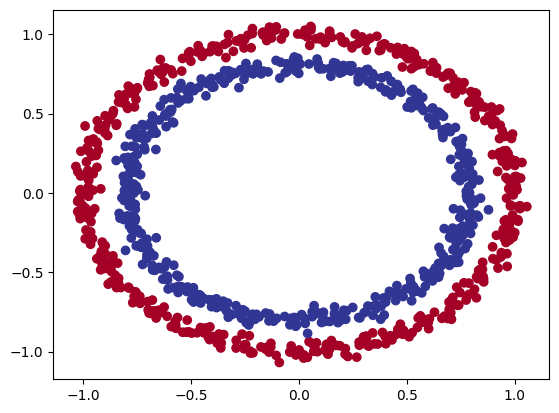

In [ ]:
# Visualize and Visualize data
import matplotlib.pyplot as plt
plt.scatter(
    x=X[:, 0],
    y=X[:, 1],
    c=Y,
    cmap=plt.cm.RdYlBu
)
plt.show()

In [ ]:
import torch
from torch import nn

device = "cuda" if torch.cuda.is_available() else "cpu"
device

# check the type of X and Y
print(type(X))
print(type(Y))

# Since they are numpy arrays and we want the tensors so we need to convert them
# into pytorch tensor

X = torch.from_numpy(X).type(torch.float)
Y = torch.from_numpy(Y).type(torch.float)

#now they are tensor type
print(type(X))
print(type(Y))


X_train , X_test, Y_train, Y_test = train_test_split(
    X,Y,
    test_size=0.2,
    random_state=28
)
X_train.shape, X_test.shape, Y_train.shape, Y_test.shape


<class 'numpy.ndarray'>
<class 'numpy.ndarray'>
<class 'torch.Tensor'>
<class 'torch.Tensor'>


(torch.Size([800, 2]),
 torch.Size([200, 2]),
 torch.Size([800]),
 torch.Size([200]))

# Model_0 : Plain simple model

In [ ]:
# Build the model

class CircleClasifierV0(nn.Module):
  def __init__(self):
    super().__init__()
    # self.layer_1 = nn.Linear(in_features=2,out_features=5)
    # self.layer_2 = nn.Linear(in_features=5, out_features=1)
    # self.sigmoid = nn.Sigmoid()
    self.layer_stack = nn.Sequential(
        nn.Linear(in_features=2,out_features=5),
        nn.Linear(in_features=5, out_features=1),
    )

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    #return self.sigmoid(self.layer_2(self.layer_1(x)))
    return self.layer_stack(x)


In [ ]:
model_0 = CircleClasifierV0().to(device)
model_0

CircleClasifierV0(
  (layer_stack): Sequential(
    (0): Linear(in_features=2, out_features=5, bias=True)
    (1): Linear(in_features=5, out_features=1, bias=True)
  )
)

In [ ]:
model_0.state_dict()

OrderedDict([('layer_stack.0.weight',
              tensor([[ 0.1803,  0.3263],
                      [ 0.2508,  0.3367],
                      [ 0.6952, -0.6402],
                      [ 0.4011,  0.2113],
                      [-0.6860, -0.2432]])),
             ('layer_stack.0.bias',
              tensor([ 0.4444, -0.0209,  0.3811,  0.3380, -0.0010])),
             ('layer_stack.1.weight',
              tensor([[-0.2057,  0.0673, -0.3819,  0.4102, -0.0957]])),
             ('layer_stack.1.bias', tensor([-0.1508]))])

In [ ]:
# loss function
loss_fn = nn.BCEWithLogitsLoss()

# optimizer
optimizer = torch.optim.SGD(params=model_0.parameters(), lr=0.1)

#accuracy function
def accuracy_fn(y_true, y_pred):
  correct = torch.eq(y_true, y_pred).sum().item()
  acc = (correct/len(y_pred)) * 100
  return acc

In [ ]:
# lets test the model
with torch.inference_mode():
  y_logits = model_0(X_test.to(device))
  y_preds = torch.round(torch.sigmoid(y_logits))

y_logits, y_preds, Y_test

(tensor([[-0.1401],
         [-0.0403],
         [-0.2536],
         [-0.0138],
         [-0.2210],
         [-0.0681],
         [-0.4070],
         [-0.0345],
         [-0.0640],
         [-0.0033],
         [-0.3926],
         [-0.2560],
         [-0.5081],
         [-0.1907],
         [-0.1875],
         [-0.5013],
         [-0.3680],
         [-0.2320],
         [-0.2232],
         [-0.2953],
         [-0.5595],
         [-0.2394],
         [-0.0413],
         [-0.2513],
         [ 0.0626],
         [-0.4440],
         [-0.1288],
         [-0.3135],
         [-0.4881],
         [-0.0808],
         [-0.3538],
         [ 0.0707],
         [-0.1097],
         [-0.1907],
         [ 0.0349],
         [-0.4765],
         [-0.0837],
         [-0.0138],
         [ 0.0582],
         [-0.0447],
         [-0.4896],
         [-0.1629],
         [ 0.0177],
         [ 0.0283],
         [-0.3119],
         [-0.4032],
         [-0.1655],
         [-0.3843],
         [-0.0939],
         [-0.5673],


In [ ]:
#Training loop for model

# setting the seed for random numbers
torch.manual_seed(28)
torch.cuda.manual_seed(28)

#epochs
epochs = 100

#move the inputs to the GPU
X_train, Y_train = X_train.to(device), Y_train.to(device)
X_test, Y_test = X_test.to(device), Y_test.to(device)

#training loop
for epoch in range(epochs):

  #put the model in training mode
  model_0.train()

  # forget the old gradients
  model_0.zero_grad()

  #forward pass
  y_logits = model_0(X_train.to(device)).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  # calculate the loss (BCEWithLogitsLoss)
  loss = loss_fn(y_logits, Y_train)
  acc = accuracy_fn(Y_train, y_preds)

  #backward pass
  loss.backward()

  #optimizer step (SGD)
  optimizer.step()

  ##Testing
  model_0.eval()

  with torch.inference_mode():
    #Forward pass
    test_logits = model_0(X_test).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    #calculate loss/acc
    test_loss = loss_fn(test_logits, Y_test)
    test_acc = accuracy_fn(Y_test, test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")




Epoch: 0 | Loss: 0.70272 | Acc: 42.38% | Test Loss: 0.71663 | Test Acc: 42.00%
Epoch: 10 | Loss: 0.69848 | Acc: 47.38% | Test Loss: 0.70867 | Test Acc: 44.00%
Epoch: 20 | Loss: 0.69652 | Acc: 47.88% | Test Loss: 0.70431 | Test Acc: 45.00%
Epoch: 30 | Loss: 0.69548 | Acc: 48.75% | Test Loss: 0.70172 | Test Acc: 45.50%
Epoch: 40 | Loss: 0.69486 | Acc: 48.88% | Test Loss: 0.70010 | Test Acc: 44.50%
Epoch: 50 | Loss: 0.69443 | Acc: 49.38% | Test Loss: 0.69902 | Test Acc: 45.50%
Epoch: 60 | Loss: 0.69412 | Acc: 49.38% | Test Loss: 0.69828 | Test Acc: 45.50%
Epoch: 70 | Loss: 0.69388 | Acc: 49.50% | Test Loss: 0.69775 | Test Acc: 46.00%
Epoch: 80 | Loss: 0.69370 | Acc: 49.00% | Test Loss: 0.69736 | Test Acc: 45.50%
Epoch: 90 | Loss: 0.69354 | Acc: 48.75% | Test Loss: 0.69706 | Test Acc: 45.00%


In [ ]:
def plot_decision_boundary(model: torch.nn.Module, X: torch.Tensor, y: torch.Tensor):
    """Plots decision boundaries of model predicting on X in comparison to y.

    Source - https://madewithml.com/courses/foundations/neural-networks/ (with modifications)
    """
    # Put everything to CPU (works better with NumPy + Matplotlib)
    model.to("cpu")
    X, y = X.to("cpu"), y.to("cpu")

    # Setup prediction boundaries and grid
    x_min, x_max = X[:, 0].min() - 0.1, X[:, 0].max() + 0.1
    y_min, y_max = X[:, 1].min() - 0.1, X[:, 1].max() + 0.1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 101), np.linspace(y_min, y_max, 101))

    # Make features
    X_to_pred_on = torch.from_numpy(np.column_stack((xx.ravel(), yy.ravel()))).float()

    # Make predictions
    model.eval()
    with torch.inference_mode():
        y_logits = model(X_to_pred_on)

    # Test for multi-class or binary and adjust logits to prediction labels
    if len(torch.unique(y)) > 2:
        y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)  # mutli-class
    else:
        y_pred = torch.round(torch.sigmoid(y_logits))  # binary

    # Reshape preds and plot
    y_pred = y_pred.reshape(xx.shape).detach().numpy()
    plt.contourf(xx, yy, y_pred, cmap=plt.cm.RdYlBu, alpha=0.7)
    plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
    plt.xlim(xx.min(), xx.max())
    plt.ylim(yy.min(), yy.max())

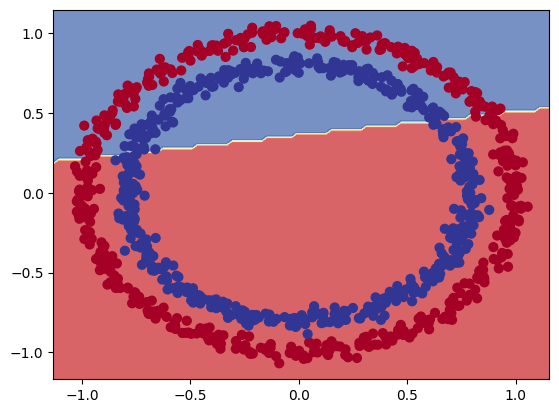

In [ ]:
plot_decision_boundary(model=model_0, X=X, y=Y)

# What can we do to improve the model
1) increase the layers
2) increase the nerons in each layer
3) change the loss function
4) change learning rate
3) train for longer (more epochs)



# Model_1 : Model with more layer and Nerons

In [ ]:
from matplotlib.cbook import safe_first_element
class CircleClasifierV1(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.layer_3(self.layer_2(self.layer_1(x)))



model_1 = CircleClasifierV1().to(device)
model_1

CircleClasifierV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [ ]:
model_1.state_dict()

OrderedDict([('layer_1.weight',
              tensor([[ 0.1803,  0.3263],
                      [ 0.2508,  0.3367],
                      [ 0.6952, -0.6402],
                      [ 0.4011,  0.2113],
                      [-0.6860, -0.2432],
                      [ 0.4444, -0.0209],
                      [ 0.3811,  0.3380],
                      [-0.0010, -0.3253],
                      [ 0.1064, -0.6038],
                      [ 0.6486, -0.1513]])),
             ('layer_1.bias',
              tensor([-0.2384,  0.6607,  0.0333, -0.6835, -0.5502,  0.3198,  0.3487,  0.4088,
                      -0.4364, -0.4926])),
             ('layer_2.weight',
              tensor([[ 2.9192e-01,  1.4120e-01, -1.5318e-01,  3.2615e-02,  4.1785e-02,
                       -2.9269e-01, -1.7187e-01, -7.9857e-02,  1.4638e-01,  8.9938e-02],
                      [ 2.2612e-01,  2.8653e-02,  2.9701e-01, -1.4805e-01, -1.4121e-03,
                       -2.9851e-02,  2.9900e-01,  9.4816e-02,  1.3118e-01,  2.805

In [ ]:
#otimizer and loss function

optimizer = torch.optim.SGD(params=model_1.parameters(), lr= 0.1)
loss_fn = nn.BCEWithLogitsLoss()


In [ ]:
# training and testing loop

torch.cuda.manual_seed(28)
torch.manual_seed(28)

# how many times are you going to train the data
epochs = 100

#training loop
for epoch in range(epochs):

  #1 put the model in traing mode
  model_1.train()

  #2 forward pass
  y_logits = model_1(X_train.to(device)).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  #Calculate the loss
  loss = loss_fn(y_logits, Y_train)
  acc = accuracy_fn(Y_train, y_preds)

  #Optimizer zero_grad
  optimizer.zero_grad()

  #update the weights
  loss.backward()

  #optimizer step
  optimizer.step()

  #Testing
  model_1.eval()

  with torch.inference_mode():
    test_logits = model_1(X_test.to(device)).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    #calculate loss/acc
    test_loss = loss_fn(test_logits, Y_test)
    test_acc = accuracy_fn(Y_test, test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.69298 | Acc: 48.00% | Test Loss: 0.69577 | Test Acc: 45.00%
Epoch: 10 | Loss: 0.69298 | Acc: 48.00% | Test Loss: 0.69577 | Test Acc: 45.00%
Epoch: 20 | Loss: 0.69298 | Acc: 48.00% | Test Loss: 0.69577 | Test Acc: 45.00%
Epoch: 30 | Loss: 0.69298 | Acc: 48.00% | Test Loss: 0.69577 | Test Acc: 45.00%
Epoch: 40 | Loss: 0.69298 | Acc: 48.00% | Test Loss: 0.69577 | Test Acc: 45.00%
Epoch: 50 | Loss: 0.69298 | Acc: 48.00% | Test Loss: 0.69577 | Test Acc: 45.00%
Epoch: 60 | Loss: 0.69298 | Acc: 48.00% | Test Loss: 0.69577 | Test Acc: 45.00%
Epoch: 70 | Loss: 0.69298 | Acc: 48.00% | Test Loss: 0.69577 | Test Acc: 45.00%
Epoch: 80 | Loss: 0.69298 | Acc: 48.00% | Test Loss: 0.69577 | Test Acc: 45.00%
Epoch: 90 | Loss: 0.69298 | Acc: 48.00% | Test Loss: 0.69577 | Test Acc: 45.00%


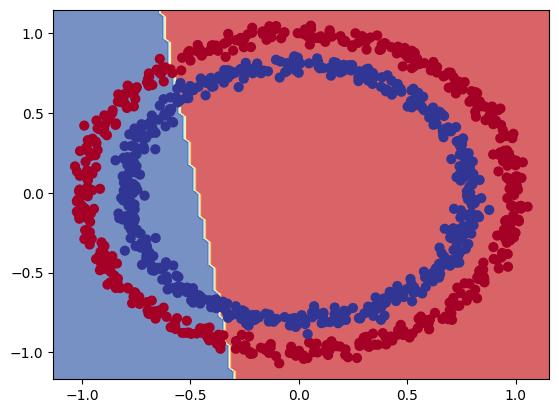

In [ ]:
plot_decision_boundary(model=model_1, X=X, y=Y)

# Model with non-linear activation function

In [ ]:
class CircleClasifierV2(nn.Module):
  def __init__(self):
    super().__init__()
    self.layer_1 = nn.Linear(in_features=2, out_features=10)
    self.layer_2 = nn.Linear(in_features=10, out_features=10)
    self.relu = nn.ReLU()
    self.layer_3 = nn.Linear(in_features=10, out_features=1)

  def forward(self, x:torch.Tensor) -> torch.Tensor:
    return self.layer_3(self.relu(self.layer_2(self.layer_1(x))))



model_2 = CircleClasifierV2().to(device)
model_2


CircleClasifierV2(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (relu): ReLU()
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

# https://playground.tensorflow.org/


In [ ]:
loss_fn = nn.BCEWithLogitsLoss()

optimizer = torch.optim.SGD(params=model_2.parameters(), lr=0.1)

In [ ]:
torch.manual_seed(28)
torch.cuda.manual_seed(28)

epochs = 1000

for epoch in range(epochs):
  model_2.train()


  # forward pass
  y_logits = model_2(X_train.to(device)).squeeze()
  y_preds = torch.round(torch.sigmoid(y_logits))

  # calculate the loss
  loss = loss_fn(y_logits, Y_train)
  acc = accuracy_fn(Y_train, y_preds)

  #zero grad
  optimizer.zero_grad()

  #backward pass
  loss.backward()

  #optimizer step
  optimizer.step()


  model_2.eval()
  with torch.inference_mode():

    #forward pass
    test_logits = model_2(X_test.to(device)).squeeze()
    test_preds = torch.round(torch.sigmoid(test_logits))

    #loss and acc
    test_loss = loss_fn(test_logits, Y_test)
    test_acc = accuracy_fn(Y_test, test_preds)

  if epoch % 10 == 0:
    print(f"Epoch: {epoch} | Loss: {loss:.5f} | Acc: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Acc: {test_acc:.2f}%")

Epoch: 0 | Loss: 0.28695 | Acc: 98.50% | Test Loss: 0.31020 | Test Acc: 97.00%
Epoch: 10 | Loss: 0.28392 | Acc: 98.50% | Test Loss: 0.30706 | Test Acc: 97.00%
Epoch: 20 | Loss: 0.28092 | Acc: 98.50% | Test Loss: 0.30392 | Test Acc: 97.00%
Epoch: 30 | Loss: 0.27795 | Acc: 98.62% | Test Loss: 0.30096 | Test Acc: 97.00%
Epoch: 40 | Loss: 0.27504 | Acc: 98.62% | Test Loss: 0.29806 | Test Acc: 97.00%
Epoch: 50 | Loss: 0.27218 | Acc: 98.75% | Test Loss: 0.29500 | Test Acc: 97.00%
Epoch: 60 | Loss: 0.26937 | Acc: 98.75% | Test Loss: 0.29204 | Test Acc: 97.50%
Epoch: 70 | Loss: 0.26663 | Acc: 98.75% | Test Loss: 0.28931 | Test Acc: 97.50%
Epoch: 80 | Loss: 0.26396 | Acc: 98.75% | Test Loss: 0.28665 | Test Acc: 97.50%
Epoch: 90 | Loss: 0.26135 | Acc: 98.75% | Test Loss: 0.28409 | Test Acc: 97.50%
Epoch: 100 | Loss: 0.25880 | Acc: 98.75% | Test Loss: 0.28155 | Test Acc: 97.50%
Epoch: 110 | Loss: 0.25629 | Acc: 98.75% | Test Loss: 0.27885 | Test Acc: 97.50%
Epoch: 120 | Loss: 0.25379 | Acc: 98.75

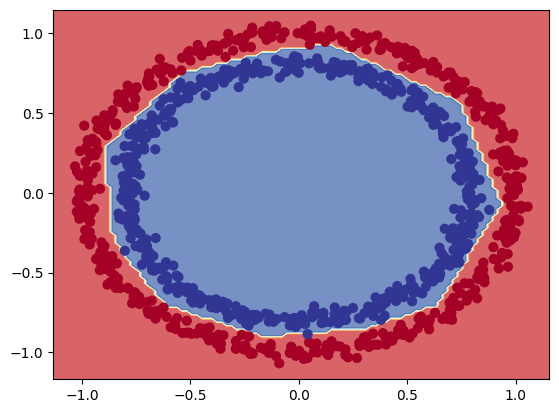

In [ ]:
plot_decision_boundary(model=model_2, X=X, y=Y)